# 종합 실습 — Oracle 데이터로 미니 EDA 리포트 만들기

- 지금까지 배운 DB 연동 → numpy 통계 → matplotlib/seaborn 시각화를 한 노트북 안에서 순서대로 종합
- "데이터를 가져와서 분석하고 보고서처럼 정리한다"는 EDA(탐색적 데이터 분석)의 전체 흐름을 체감

In [4]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np

load_dotenv()

USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")



In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rc('font', family='AppleGothic')
mpl.rc('axes', unicode_minus=False)

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with 블록을 벗어나는 순간 자동으로 연결이 닫힘
df.head()

/var/folders/4j/qgl7j0hx7y33d7l5bjgf9h9h0000gn/T/ipykernel_99133/1841599413.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
1,2,치킨,치킨,22000,4.8,서초구,2026-08-02
2,3,피자,피자,25000,4.2,강남구,2026-08-03
3,4,짜장면,중식,8000,4.0,송파구,2026-08-04
4,5,마라탕,중식,13000,4.6,강남구,2026-08-05


In [6]:
category_summary = df.groupby("CATEGORY").agg(
    평균가격 = ("PRICE", "mean"),
    평균평점 = ("RATING", "mean"),
    주문건수 = ("ORDER_ID", "count")
).sort_values("주문건수", ascending=False)

print("=== 카테고리별 요약 ===")
print(category_summary)

=== 카테고리별 요약 ===
                  평균가격      평균평점  주문건수
CATEGORY                              
중식        11800.000000  4.330000    10
일식        14687.500000  4.375000     8
분식         7642.857143  4.300000     7
치킨        22250.000000  4.716667     6
피자        25666.666667  4.200000     6


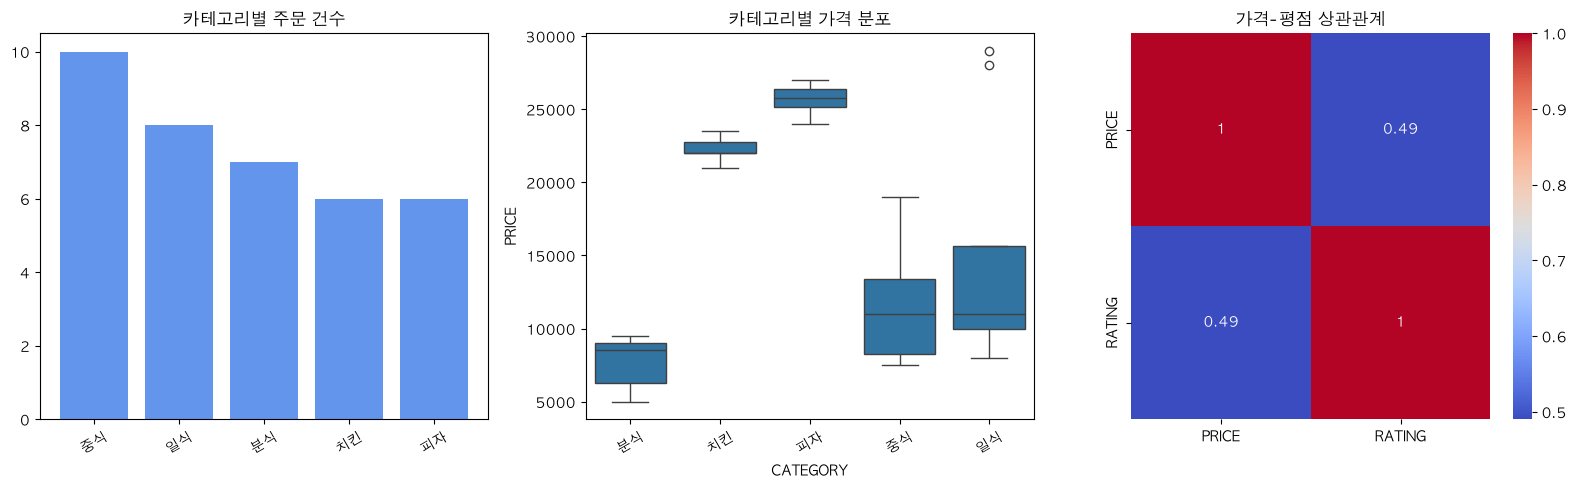

In [8]:
fig, axes = plt.subplots(1,3, figsize = (16,5))

axes[0].bar(category_summary.index, category_summary["주문건수"], color="cornflowerblue")
axes[0].set_title("카테고리별 주문 건수")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x="CATEGORY", y="PRICE", ax=axes[1])
axes[1].set_title("카테고리별 가격 분포")
axes[1].tick_params(axis='x', rotation=30)

corr = df[["PRICE","RATING"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[2])
axes[2].set_title("가격-평점 상관관계")

plt.tight_layout()
plt.show()